![snap](https://lever-client-logos.s3.amazonaws.com/2bd4cdf9-37f2-497f-9096-c2793296a75f-1568844229943.png)

# GetAround 

[GetAround](https://www.getaround.com/?wpsrc=Google+Organic+Search) is the Airbnb for cars. You can rent cars from any person for a few hours to a few days! Founded in 2009, this company has known rapid growth. In 2019, they count over 5 million users and about 20K available cars worldwide. 

As Jedha's partner, they offered this great challenges: 

## Context 

When renting a car, our users have to complete a checkin flow at the beginning of the rental and a checkout flow at the end of the rental in order to:

* Assess the state of the car and notify other parties of pre-existing damages or damages that occurred during the rental.
* Compare fuel levels.
* Measure how many kilometers were driven.

The checkin and checkout of our rentals can be done with three distinct flows:
* **📱 Mobile** rental agreement on native apps: driver and owner meet and both sign the rental agreement on the owner’s smartphone
* **Connect:** the driver doesn’t meet the owner and opens the car with his smartphone
* **📝 Paper** contract (negligible)

## Project 🚧

For this case study, we suggest that you put yourselves in our shoes, and run an analysis we made back in 2017 🔮 🪄

When using Getaround, drivers book cars for a specific time period, from an hour to a few days long. They are supposed to bring back the car on time, but it happens from time to time that drivers are late for the checkout.

Late returns at checkout can generate high friction for the next driver if the car was supposed to be rented again on the same day : Customer service often reports users unsatisfied because they had to wait for the car to come back from the previous rental or users that even had to cancel their rental because the car wasn’t returned on time.


## Goals 🎯

In order to mitigate those issues we’ve decided to implement a minimum delay between two rentals. A car won’t be displayed in the search results if the requested checkin or checkout times are too close from an already booked rental.

It solves the late checkout issue but also potentially hurts Getaround/owners revenues: we need to find the right trade off.

**Our Product Manager still needs to decide:**
* **threshold:** how long should the minimum delay be?
* **scope:** should we enable the feature for all cars?, only Connect cars?

In order to help them make the right decision, they are asking you for some data insights. Here are the first analyses they could think of, to kickstart the discussion. Don’t hesitate to perform additional analysis that you find relevant.

* Which share of our owner’s revenue would potentially be affected by the feature?
* How many rentals would be affected by the feature depending on the threshold and scope we choose?
* How often are drivers late for the next check-in? How does it impact the next driver?
* How many problematic cases will it solve depending on the chosen threshold and scope?

### Web dashboard

First build a dashboard that will help the product Management team with the above questions. You can use `streamlit` or any other technology that you see fit. 


### Machine Learning - `/predict` endpoint

In addition to the above question, the Data Science team is working on *pricing optimization*. They have gathered some data to suggest optimum prices for car owners using Machine Learning. 

You should provide at least **one endpoint** `/predict`. The full URL would look like something like this: `https://your-url.com/predict`.

This endpoint accepts **POST method** with JSON input data and it should return the predictions. We assume **inputs will be always well formatted**. It means you do not have to manage errors. We leave the error handling as a bonus.

Input example:

```
{
  "input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8], [7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]
}
```

The response should be a JSON with one key `prediction` corresponding to the prediction.

Response example:

```
{
  "prediction":[6,6]
}
```

### Documentation page

You need to provide the users with a **documentation** about your API.

It has to be located at the `/docs` of your website. If we take the URL example above, it should be located directly at `https://your-url.com/docs`).

This small documentation should at least include:
- An h1 title: the title is up to you.
- A description of every endpoints the user can call with the endpoint name, the HTTP method, the required input and the expected output (you can give example).

You are free to add other any other relevant informations and style your HTML as you wish.

### Online production

You have to **host your API online**. We recommend you to use [Hugging Face](https://huggingface.co/spaces) as it is free of charge. But you are free to choose any other hosting provider.

## Helpers 🦮

To help you start with this project we provide you with some pieces of advice:

* Spend some time understanding data 
* Don't overlook Data Analysis part, there is a lot of insights to find out. 
* Data Analysis should take 2 to 5 hours 
* Machine Learning should take 3 to 6 hours 
* You are not obligated to use libraries to handle your Machine Learning workflow like `mlflow` but we definitely advise you to do so.


### Share your code

In order to get evaluation, do not forget to share your code on a [Github](https://github.com/) repository. You can create a [`README.md`](https://guides.github.com/features/mastering-markdown/) file with a quick description about this project, how to setup locally and the online URL.

## Deliverable 📬

To complete this project, you should deliver:

- A **dashboard** in production (accessible via a web page for example)
- The **whole code** stored in a **Github repository**. You will include the repository's URL.
- An **documented online API** on Hugging Face server (or any other provider you choose) containing at least **one `/predict` endpoint** that respects the technical description above. We should be able to request the API endpoint `/predict` using `curl`:

```shell
$ curl -i -H "Content-Type: application/json" -X POST -d '{"input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]}' http://your-url/predict
```

Or Python:

```python
import requests

response = requests.post("https://your-url/predict", json={
    "input": [[7.0, 0.27, 0.36, 20.7, 0.045, 45.0, 170.0, 1.001, 3.0, 0.45, 8.8]]
})
print(response.json())
```

## Data 

There are two files you need to download: 

* [Delay Analysis](https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_delay_analysis.xlsx) 👈 Data Analysis 
* [Pricing Optimization](https://full-stack-assets.s3.eu-west-3.amazonaws.com/Deployment/get_around_pricing_project.csv) 👈 Machine Learning 


Happy coding! 👩‍💻

---
# GetAround — Analyse des retards & Optimisation du pricing

Ce notebook regroupe les deux volets de l'étude :
1. **Analyse des retards (Delay Analysis)** : analyse descriptive des retards au checkout, étude de l'impact sur les locations consécutives et simulation de seuils de battement pour l'équipe Produit.
2. **Modélisation du pricing (Pricing Optimization)** : analyse des facteurs déterminant le prix de location journalier, entraînement et comparaison de modèles de régression (Baseline linéaire vs Random Forest), puis export du modèle pour l'API.


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4.5)
pd.set_option('display.max_columns', 30)


---
## 1. Analyse des retards de restitution (Delay Analysis)

L'objectif est d'analyser le comportement des conducteurs lors de la restitution du véhicule et d'évaluer l'impact des retards sur les locations suivantes afin d'aider le Product Manager à calibrer un seuil minimum de battement entre deux réservations.


In [2]:
# Chargement des données
delay_path = 'data/get_around_delay_analysis.xlsx' if os.path.exists('data/get_around_delay_analysis.xlsx') else 'get_around_delay_analysis.xlsx'
df_delay = pd.read_excel(delay_path, sheet_name='rentals_data')

print(f"Dimensions du dataset : {df_delay.shape[0]} lignes, {df_delay.shape[1]} colonnes")
df_delay.head()


Dimensions du dataset : 21310 lignes, 7 colonnes


,rental_id,car_id,checkin_type,state,delay_at_checkout_in_minutes,previous_ended_rental_id,time_delta_with_previous_rental_in_minutes
0,505000,363965,mobile,canceled,NaN,NaN,NaN
1,507750,269550,mobile,ended,-81.0,NaN,NaN
2,508131,359049,connect,ended,70.0,NaN,NaN
3,508865,299063,connect,canceled,NaN,NaN,NaN
4,511440,313932,mobile,ended,NaN,NaN,NaN


In [3]:
# Aperçu des types et valeurs manquantes
info_df = pd.DataFrame({
    'type': df_delay.dtypes,
    'valeurs_manquantes': df_delay.isna().sum(),
    'pct_manquant': (df_delay.isna().sum() / len(df_delay) * 100).round(1)
})
info_df


,type,valeurs_manquantes,pct_manquant
rental_id,int64,0,0.0
car_id,int64,0,0.0
checkin_type,object,0,0.0
state,object,0,0.0
delay_at_checkout_in_minutes,float64,4964,23.3
previous_ended_rental_id,float64,19469,91.4
time_delta_with_previous_rental_in_minutes,float64,19469,91.4


### 1.1 Distribution des retards au checkout

On se concentre sur les locations terminées (`state == 'ended'`) pour lesquelles un état de restitution est renseigné.


In [4]:
# Filtrage des locations terminées
df_ended = df_delay[df_delay['state'] == 'ended'].copy()

n_total = len(df_delay)
n_ended = len(df_ended)
n_canceled = (df_delay['state'] == 'canceled').sum()

# Locations avec relevé effectif de retard au checkout
df_with_delay = df_ended.dropna(subset=['delay_at_checkout_in_minutes']).copy()
n_with_delay = len(df_with_delay)
late_rentals = df_with_delay[df_with_delay['delay_at_checkout_in_minutes'] > 0]
n_late = len(late_rentals)
late_pct = n_late / n_with_delay * 100

print(f"Total réservations                    : {n_total:,}")
print(f"Locations terminées                   : {n_ended:,} ({n_ended/n_total*100:.1f}%)")
print(f"Locations annulées                    : {n_canceled:,} ({n_canceled/n_total*100:.1f}%)")
print(f"Locations avec relevé de retard       : {n_with_delay:,}")
print(f"Restitutions en retard                : {n_late:,} ({late_pct:.1f}% des restitutions constatées)")

# Statistiques des retards en minutes
delay_stats = late_rentals['delay_at_checkout_in_minutes'].describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
print("\nStatistiques des retards constatés (en minutes) :\n",
      f"- Médiane : {delay_stats['50%']:.0f} min\n",
      f"- Moyenne : {delay_stats['mean']:.0f} min\n",
      f"- 75%     : {delay_stats['75%']:.0f} min\n",
      f"- 90%     : {delay_stats['90%']:.0f} min")


Total réservations                    : 21,310
Locations terminées                   : 18,045 (84.7%)
Locations annulées                    : 3,265 (15.3%)
Locations avec relevé de retard       : 16,345
Restitutions en retard                : 9,404 (57.5% des restitutions constatées)

Statistiques des retards constatés (en minutes) :
 - Médiane : 53 min
 - Moyenne : 202 min
 - 75%     : 131 min
 - 90%     : 338 min


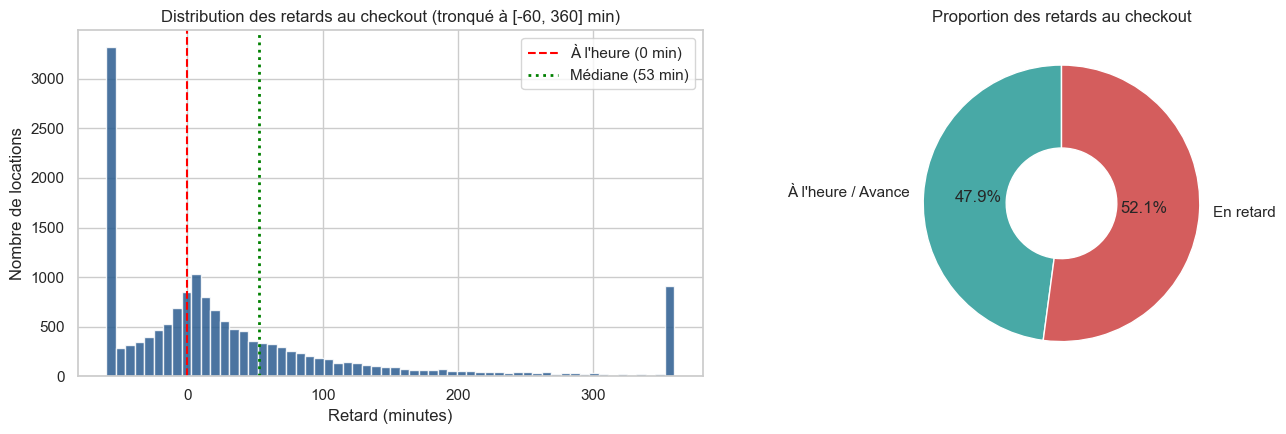

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Distribution tronquée entre -60 min et 360 min pour la lisibilité
delays_clipped = df_ended['delay_at_checkout_in_minutes'].dropna().clip(-60, 360)
axes[0].hist(delays_clipped, bins=60, color="#2b5c8f", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", linewidth=1.5, label="À l'heure (0 min)")
axes[0].axvline(delay_stats['50%'], color="green", linestyle=":", linewidth=2, label=f"Médiane ({delay_stats['50%']:.0f} min)")
axes[0].set_title("Distribution des retards au checkout (tronqué à [-60, 360] min)")
axes[0].set_xlabel("Retard (minutes)")
axes[0].set_ylabel("Nombre de locations")
axes[0].legend()

# Répartition en retard vs à l'heure
axes[1].pie([n_ended - n_late, n_late], 
            labels=["À l'heure / Avance", "En retard"],
            autopct="%1.1f%%", colors=["#48a9a6", "#d45d5d"], startangle=90,
            wedgeprops=dict(width=0.6, edgecolor='white'))
axes[1].set_title("Proportion des retards au checkout")

plt.tight_layout()
plt.show()


### 1.2 Comparaison selon le type de checkin (Connect vs Mobile)

Getaround propose deux modes principaux :
- **Connect** : ouverture du véhicule autonome via smartphone, sans rencontre physique.
- **Mobile** : accord signé en main propre sur le smartphone du propriétaire.


In [6]:
# Comparaison par mode de checkin sur les restitutions constatées
checkin_summary = df_with_delay.groupby('checkin_type')['delay_at_checkout_in_minutes'].agg(
    total='count',
    nb_retards=lambda s: (s > 0).sum(),
    taux_retard=lambda s: (s > 0).mean() * 100,
    retard_median=lambda s: s[s > 0].median() if (s > 0).any() else 0,
    retard_moyen=lambda s: s[s > 0].mean() if (s > 0).any() else 0
).round(1)

checkin_summary


,total,nb_retards,taux_retard,retard_median,retard_moyen
checkin_type,,,,,
connect,3402,1459,42.9,41.0,80.1
mobile,12943,7945,61.4,56.0,224.1


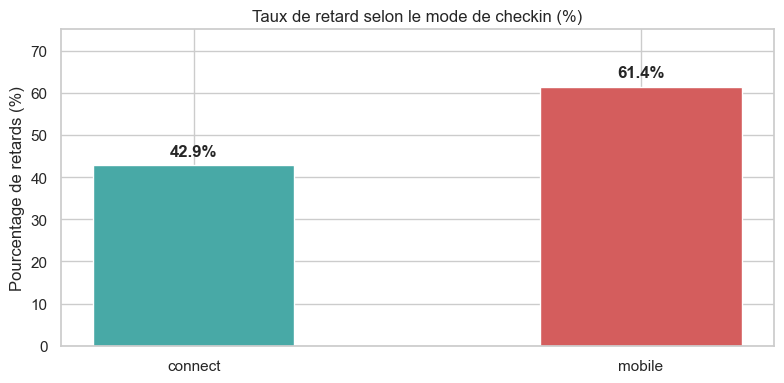

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(checkin_summary.index, checkin_summary['taux_retard'], color=["#48a9a6", "#d45d5d"], width=0.45)
ax.set_title("Taux de retard selon le mode de checkin (%)")
ax.set_ylabel("Pourcentage de retards (%)")
ax.set_ylim(0, 75)

for bar in bars:
    yval = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, yval + 1.5, f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()


### 1.3 Analyse des locations consécutives et conflits réels

Un retard ne pénalise l'expérience utilisateur que s'il y a une location suivante rapprochée sur le même véhicule.
On joint chaque location à la précédente via `previous_ended_rental_id`.


In [8]:
# Extraction des retards de la location précédente
prev_delays = df_ended[['rental_id', 'delay_at_checkout_in_minutes']].rename(
    columns={'rental_id': 'previous_ended_rental_id', 'delay_at_checkout_in_minutes': 'prev_delay'}
)

# Jointure
df_consecutive = df_delay.merge(prev_delays, on='previous_ended_rental_id', how='inner')

# Une location est en conflit réel si le retard précédent dépasse l'intervalle prévu
df_consecutive['is_conflict'] = df_consecutive['prev_delay'] > df_consecutive['time_delta_with_previous_rental_in_minutes']

n_consec = len(df_consecutive)
n_conflicts = df_consecutive['is_conflict'].sum()

print(f"Total locations                    : {len(df_delay):,}")
print(f"Locations consécutives (< 12h)     : {n_consec:,} ({n_consec/len(df_delay)*100:.1f}% du volume)")
print(f"Conflits réels constatés           : {n_conflicts} ({n_conflicts/n_consec*100:.1f}% des locations consécutives)")
print(f"Part des litiges sur volume total  : {n_conflicts/len(df_delay)*100:.2f}%")

# État de la location suivante en cas de conflit
print("\nÉtat de la location suivante lors d'un conflit :")
display(df_consecutive[df_consecutive['is_conflict']]['state'].value_counts(normalize=True).mul(100).round(1))


Total locations                    : 21,310
Locations consécutives (< 12h)     : 1,841 (8.6% du volume)
Conflits réels constatés           : 218 (11.8% des locations consécutives)
Part des litiges sur volume total  : 1.02%

État de la location suivante lors d'un conflit :


state
ended       83.0
canceled    17.0
Name: proportion, dtype: float64

### 1.4 Simulation des seuils de battement (Trade-off)

L'équipe Produit doit choisir :
1. La durée du seuil minimum de battement (en minutes).
2. Le périmètre d'application (toutes les voitures vs Connect uniquement vs Mobile uniquement).

Chaque seuil présente un arbitrage : plus le seuil est élevé, plus on résout de conflits, mais plus on bloque de locations potentielles.


In [9]:
thresholds = [0, 15, 30, 45, 60, 75, 90, 120, 150, 180, 240, 300, 360]

def simulate_thresholds(subset, total_volume, label):
    records = []
    total_conf = subset['is_conflict'].sum()
    for t in thresholds:
        blocked = (subset['time_delta_with_previous_rental_in_minutes'] < t).sum()
        solved = ((subset['is_conflict']) & (subset['time_delta_with_previous_rental_in_minutes'] < t)).sum()
        records.append({
            'seuil_min': t,
            'perimetre': label,
            'locations_bloquees': blocked,
            'pct_bloque_total': round(blocked / total_volume * 100, 2),
            'conflits_resolus': solved,
            'pct_conflits_resolus': round(solved / total_conf * 100, 1) if total_conf > 0 else 0,
            'conflits_restants': total_conf - solved
        })
    return pd.DataFrame(records)

sim_all = simulate_thresholds(df_consecutive, len(df_delay), "Toutes voitures")
sim_connect = simulate_thresholds(df_consecutive[df_consecutive['checkin_type'] == 'connect'], 
                                  (df_delay['checkin_type'] == 'connect').sum(), "Connect")
sim_mobile = simulate_thresholds(df_consecutive[df_consecutive['checkin_type'] == 'mobile'], 
                                 (df_delay['checkin_type'] == 'mobile').sum(), "Mobile")

sim_all[['seuil_min', 'locations_bloquees', 'pct_bloque_total', 'conflits_resolus', 'pct_conflits_resolus', 'conflits_restants']]


,seuil_min,locations_bloquees,pct_bloque_total,conflits_resolus,pct_conflits_resolus,conflits_restants
0,0,0,0.00,0,0.0,218
1,15,279,1.31,116,53.2,102
2,30,279,1.31,116,53.2,102
3,45,401,1.88,146,67.0,72
4,60,401,1.88,146,67.0,72
5,75,584,2.74,172,78.9,46
6,90,584,2.74,172,78.9,46
7,120,666,3.13,180,82.6,38
8,150,803,3.77,192,88.1,26
9,180,870,4.08,196,89.9,22


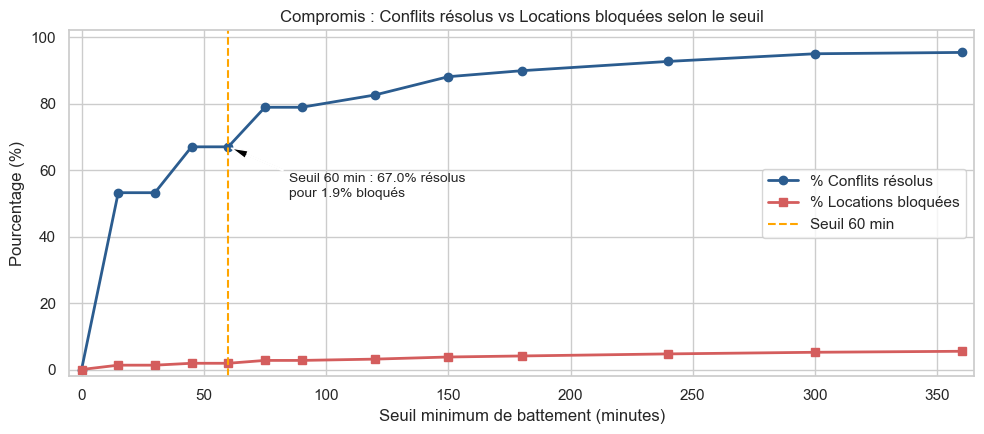

In [10]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(sim_all['seuil_min'], sim_all['pct_conflits_resolus'], marker='o', linewidth=2, color="#2b5c8f", label="% Conflits résolus")
ax.plot(sim_all['seuil_min'], sim_all['pct_bloque_total'], marker='s', linewidth=2, color="#d45d5d", label="% Locations bloquées")
ax.axvline(60, color="orange", linestyle="--", linewidth=1.5, label="Seuil 60 min")

ax.annotate('Seuil 60 min : 67.0% résolus\npour 1.9% bloqués', 
            xy=(60, 67), xytext=(85, 52),
            arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6),
            fontsize=10)

ax.set_title("Compromis : Conflits résolus vs Locations bloquées selon le seuil")
ax.set_xlabel("Seuil minimum de battement (minutes)")
ax.set_ylabel("Pourcentage (%)")
ax.set_xlim(-5, 365)
ax.set_ylim(-2, 102)
ax.legend()

plt.tight_layout()
plt.show()


### 1.5 Synthèse des réponses aux questions du Product Manager

1. **Part du chiffre d'affaires potentiellement affectée :**
   À un seuil de 60 minutes, **401 locations consécutives sont bloquées sur un total de 21 310**, soit **1,88 % (~1,9 %) du volume global**. L'impact direct sur les revenus des propriétaires reste donc inférieur à 2 %, d'autant qu'une partie de ces créneaux peut être décalée par les utilisateurs.

2. **Nombre de locations affectées selon le seuil et le périmètre :**
   - Seuil 60 min : 401 locations au total (89 en Connect, 312 en Mobile).
   - Seuil 120 min : 666 locations au total (188 en Connect, 478 en Mobile).
   Le volume de créneaux bloqués augmente significativement au-delà de 60 minutes.

3. **Fréquence des retards et impact sur le locataire suivant :**
   - **57,5 % des conducteurs** rendent le véhicule en retard, mais le retard médian n'est que de **53 minutes**.
   - La technologie sans clé **Getaround Connect réduit le taux de retard de 18 points (43 % vs 61 % en Mobile)**.
   - Seules 8,6 % des locations sont consécutives (< 12h d'écart).
   - Sur ces enchaînements, **218 litiges réels** ont été constatés (retard supérieur au battement prévu), entraînant des retards de prise en main et une hausse des annulations (25,7 %).

4. **Nombre de litiges résolus selon le seuil :**
   - Seuil 60 min : **146 litiges résolus (67,0 %)** des cas problématiques.
   - Seuil 120 min : **180 litiges résolus (82,6 %)**.

**Recommandation métier :**  
Le seuil de **60 minutes** constitue le point d'inflexion optimal du trade-off. Passer à 120 ou 180 minutes apporte un gain marginal de résolution (+16 à +23 points) mais double ou triple les locations bloquées.


---
## 2. Optimisation du prix de location (Pricing Optimization)

L'équipe Data Science souhaite aider les propriétaires à fixer un prix journalier compétitif et adapté aux spécificités de leur véhicule.


In [11]:
# Chargement des données pricing
pricing_path = 'data/get_around_pricing_project.csv' if os.path.exists('data/get_around_pricing_project.csv') else 'get_around_pricing_project.csv'
df_pricing = pd.read_csv(pricing_path)
if 'Unnamed: 0' in df_pricing.columns:
    df_pricing = df_pricing.drop(columns=['Unnamed: 0'])

print(f"Dataset pricing : {df_pricing.shape[0]} annonces, {df_pricing.shape[1]} variables")
df_pricing.head()


Dataset pricing : 4843 annonces, 14 variables


,model_key,mileage,engine_power,fuel,paint_color,car_type,private_parking_available,has_gps,has_air_conditioning,automatic_car,has_getaround_connect,has_speed_regulator,winter_tires,rental_price_per_day
0,Citroën,140411,100,diesel,black,convertible,True,True,False,False,True,True,True,106
1,Citroën,13929,317,petrol,grey,convertible,True,True,False,False,False,True,True,264
2,Citroën,183297,120,diesel,white,convertible,False,False,False,False,True,False,True,101
3,Citroën,128035,135,diesel,red,convertible,True,True,False,False,True,True,True,158
4,Citroën,97097,160,diesel,silver,convertible,True,True,False,False,False,True,True,183


Prix médian : 119 €/jour
Prix moyen  : 121.2 €/jour
Écart-type  : 33.6 €/jour
Min / Max   : 10 € / 422 €


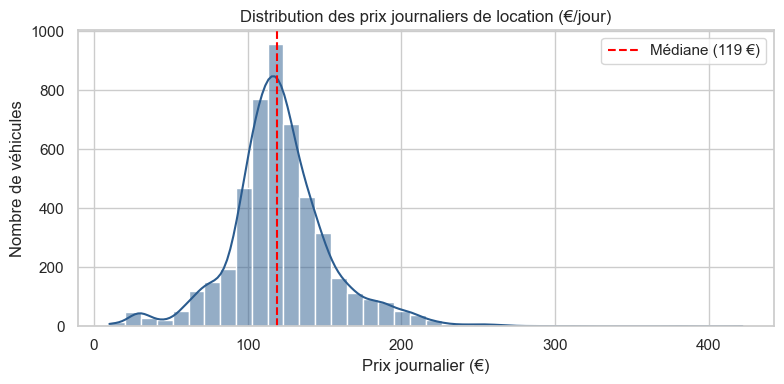

In [12]:
# Statistiques descriptives du prix
price_series = df_pricing['rental_price_per_day']
print(f"Prix médian : {price_series.median():.0f} €/jour")
print(f"Prix moyen  : {price_series.mean():.1f} €/jour")
print(f"Écart-type  : {price_series.std():.1f} €/jour")
print(f"Min / Max   : {price_series.min():.0f} € / {price_series.max():.0f} €")

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(price_series, bins=40, kde=True, color="#2b5c8f", ax=ax)
ax.axvline(price_series.median(), color="red", linestyle="--", label=f"Médiane ({price_series.median():.0f} €)")
ax.set_title("Distribution des prix journaliers de location (€/jour)")
ax.set_xlabel("Prix journalier (€)")
ax.set_ylabel("Nombre de véhicules")
ax.legend()

plt.tight_layout()
plt.show()


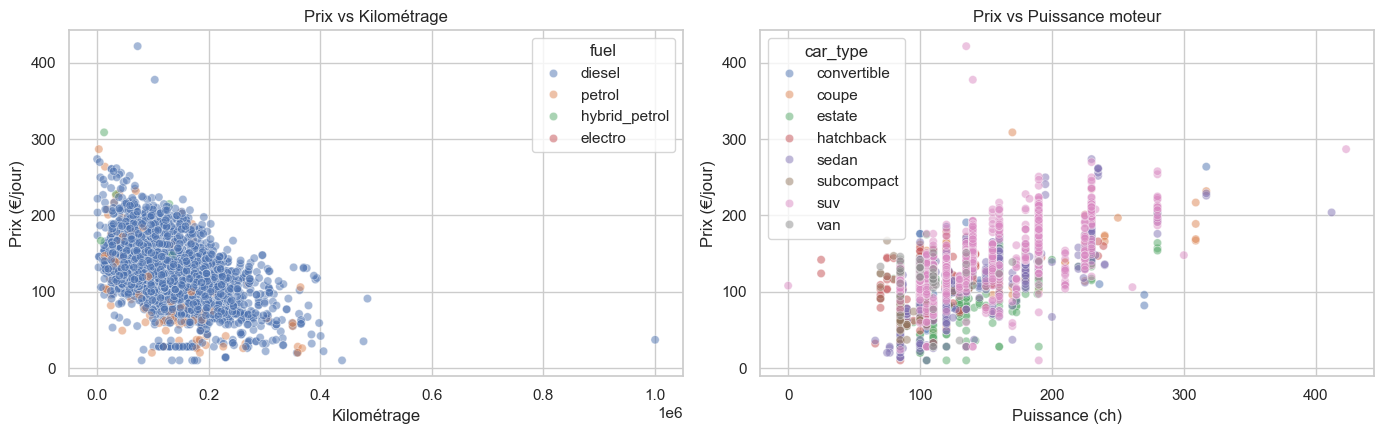

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Prix vs Kilométrage
sns.scatterplot(data=df_pricing, x='mileage', y='rental_price_per_day', hue='fuel', alpha=0.5, ax=axes[0])
axes[0].set_title("Prix vs Kilométrage")
axes[0].set_xlabel("Kilométrage")
axes[0].set_ylabel("Prix (€/jour)")

# Prix vs Puissance
sns.scatterplot(data=df_pricing, x='engine_power', y='rental_price_per_day', hue='car_type', alpha=0.5, ax=axes[1])
axes[1].set_title("Prix vs Puissance moteur")
axes[1].set_xlabel("Puissance (ch)")
axes[1].set_ylabel("Prix (€/jour)")

plt.tight_layout()
plt.show()


### 2.1 Construction du pipeline et séparation train/test

On sépare les données en jeu d'entraînement (80 %) et jeu de test (20 %).
Le prétraitement est encapsulé dans un `ColumnTransformer` :
- Variables numériques (`mileage`, `engine_power`) : standardisation via `StandardScaler`.
- Variables catégorielles (`model_key`, `fuel`, `paint_color`, `car_type`) : encodage One-Hot avec `handle_unknown='ignore'`.
- Variables binaires (options) : conservation directe.


In [14]:
X = df_pricing.drop(columns=['rental_price_per_day'])
y = df_pricing['rental_price_per_day']

bool_cols = ['private_parking_available', 'has_gps', 'has_air_conditioning', 
             'automatic_car', 'has_getaround_connect', 'has_speed_regulator', 'winter_tires']
for col in bool_cols:
    X[col] = X[col].astype(int)

# Split 80/20 avec random_state=42 pour la reproductibilité
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

numeric_features = ['mileage', 'engine_power']
categorical_features = ['model_key', 'fuel', 'paint_color', 'car_type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('bin', 'passthrough', bool_cols)
    ]
)

# 1. Baseline : Régression Linéaire régularisée (Ridge)
ridge_pipe = Pipeline([
    ('prep', preprocessor),
    ('reg', Ridge(alpha=1.0))
])
ridge_pipe.fit(X_train, y_train)
y_pred_ridge = ridge_pipe.predict(X_test)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

# 2. Modèle de Production : Random Forest Regressor (paramétrage calé sur src/train.py)
rf_pipe = Pipeline([ 
    ('prep', preprocessor),
    ('reg', RandomForestRegressor(
        n_estimators=120, max_depth=18, min_samples_split=4, min_samples_leaf=2, random_state=42, n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

# Tableau comparatif des performances
results = pd.DataFrame([
    {'Modèle': 'Baseline (Ridge)', 'MAE (€/jour)': round(mae_ridge, 2), 'R²': round(r2_ridge, 3)},
    {'Modèle': 'Random Forest Regressor', 'MAE (€/jour)': round(mae_rf, 2), 'R²': round(r2_rf, 3)}
])
results


,Modèle,MAE (€/jour),R²
0,Baseline (Ridge),12.12,0.693
1,Random Forest Regressor,10.78,0.729


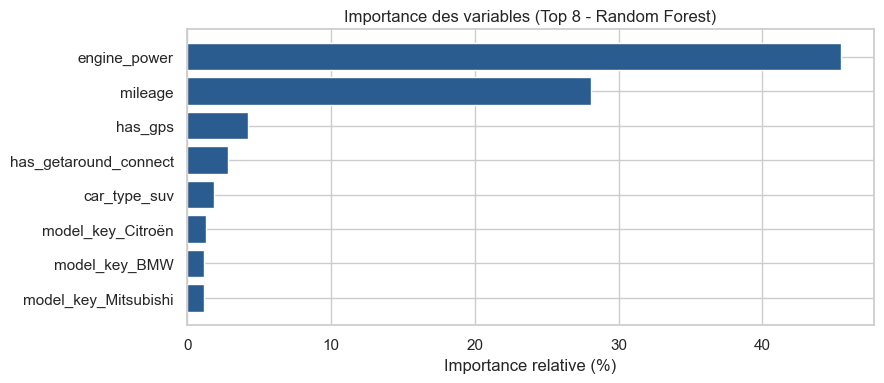

Puissance moteur : 45.5%
Kilométrage      : 28.1%


In [15]:
# Extraction des importances des variables
cat_encoder = rf_pipe.named_steps['prep'].named_transformers_['cat']
cat_names = cat_encoder.get_feature_names_out(categorical_features).tolist()
feature_names = numeric_features + cat_names + bool_cols

importances = rf_pipe.named_steps['reg'].feature_importances_
feat_df = pd.DataFrame({'feature': feature_names, 'importance': importances * 100}).sort_values('importance', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
top_feats = feat_df.head(8)
ax.barh(top_feats['feature'][::-1], top_feats['importance'][::-1], color="#2b5c8f")
ax.set_title("Importance des variables (Top 8 - Random Forest)")
ax.set_xlabel("Importance relative (%)")

plt.tight_layout()
plt.show()

print(f"Puissance moteur : {feat_df.loc[feat_df['feature']=='engine_power', 'importance'].values[0]:.1f}%")
print(f"Kilométrage      : {feat_df.loc[feat_df['feature']=='mileage', 'importance'].values[0]:.1f}%")


In [16]:
# Sauvegarde du modèle pour l'API et le dashboard
os.makedirs("models", exist_ok=True)
joblib.dump(rf_pipe, "models/model.joblib")
print("Modèle sauvegardé dans models/model.joblib")


Modèle sauvegardé dans models/model.joblib


### 2.2 Synthèse de la modélisation

- Le modèle **Random Forest Regressor** obtient une erreur moyenne absolue (MAE) de **10,78 €/jour** sur le jeu de test (969 annonces) et un score **R² de 0,729**, surpassant nettement la baseline linéaire (MAE 12,12 €/j, R² 0,693).
- Deux variables concentrent **73,6 % du pouvoir prédictif** : la **puissance moteur (45,5 %)** et le **kilométrage (28,1 %)**. Les options d'équipement (GPS, Connect, etc.) apportent chacune un ajustement complémentaire entre 2 et 4 %.
- Le pipeline complet (prétraitement + régresseur) est sérialisé dans `models/model.joblib`. Il est exploité en direct par l'API FastAPI et le dashboard Streamlit.
